В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import statsmodels.api as sm

from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [22]:
cars_df = pd.read_csv('cars.csv')
cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [23]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [24]:
cars_df.describe()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,50.500000,2018.39000,28150.000000,17.210000,1855.230000,158.130000,5.230000,1.574000e+06
std,29.011492,1.17116,9121.375716,3.309902,631.311475,76.968137,0.750151,1.000265e+06
min,1.000000,2016.00000,10000.000000,10.000000,999.000000,68.000000,4.000000,4.500000e+05
25%,25.750000,2017.75000,22000.000000,15.000000,1462.000000,103.000000,5.000000,7.000000e+05
50%,50.500000,2018.00000,27000.000000,17.000000,1774.000000,148.000000,5.000000,1.300000e+06
75%,75.250000,2019.00000,32000.000000,19.000000,2143.000000,187.000000,5.000000,2.500000e+06
max,100.000000,2021.00000,60000.000000,25.000000,4951.000000,396.000000,7.000000,4.000000e+06


In [25]:
display("Object columns", cars_df.select_dtypes(include = "object").columns)
display("Number columns", cars_df.select_dtypes(include = "number").columns)

'Object columns'

Index(['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type'], dtype='object')

'Number columns'

Index(['Car_ID', 'Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power',
       'Seats', 'Price'],
      dtype='object')

In [26]:
display(cars_df['Brand'].unique(), len(cars_df['Brand'].unique()))
display(cars_df['Model'].unique(), len(cars_df['Model'].unique()))
display(cars_df['Fuel_Type'].unique(), len(cars_df['Fuel_Type'].unique()))
display(cars_df['Transmission'].unique(), len(cars_df['Transmission'].unique()))
display(cars_df['Owner_Type'].unique(), len(cars_df['Owner_Type'].unique()))

array(['Toyota', 'Honda', 'Ford', 'Maruti', 'Hyundai', 'Tata', 'Mahindra',
       'Volkswagen', 'Audi', 'BMW', 'Mercedes'], dtype=object)

11

array(['Corolla', 'Civic', 'Mustang', 'Swift', 'Sonata', 'Nexon',
       'Scorpio', 'Polo', 'A4', 'X1', 'C-Class', 'Endeavour', 'Creta',
       'Harrier', 'Ertiga', 'City', 'Tiguan', 'Q3', '5 Series', 'GLC',
       'Innova', 'Figo', 'Verna', 'Altroz', 'Thar', 'Passat', 'A6', 'X3',
       'E-Class', 'Fortuner', 'Aspire', 'Elantra', 'Safari', 'Vitara',
       'WR-V', 'Ameo', 'A3', '7 Series', 'GLE', 'Yaris', 'Ranger',
       'Santro', 'Tigor', 'S-Cross', 'BR-V', 'T-Roc', 'Q7', 'X5', 'GLA',
       'Camry', 'Venue', 'Tiago', 'XUV300', 'Vento', 'A5', '3 Series',
       'Innova Crysta', 'EcoSport'], dtype=object)

58

array(['Petrol', 'Diesel'], dtype=object)

2

array(['Manual', 'Automatic'], dtype=object)

2

array(['First', 'Second', 'Third'], dtype=object)

3

В наборі даних 8 числових і 5 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення) (Fuel_Type, Transmission)
- 2 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку (Brand, Model)
- 1 колонка, в якій можна встановити відношення порядку (Owner_Type : First<Second<Third)

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [27]:
target_column = ['Price']
input_columns = list(set(cars_df.columns) - set(target_column))
target = cars_df[target_column]
inputs = cars_df[input_columns]
X_train, X_test, y_train, y_test = train_test_split(inputs, target, test_size=0.2, random_state=12)

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [28]:
display(cars_df['Fuel_Type'].value_counts())
display(cars_df['Transmission'].value_counts())

Fuel_Type
Petrol    52
Diesel    48
Name: count, dtype: int64

Transmission
Automatic    57
Manual       43
Name: count, dtype: int64

In [42]:
fuel_type_codes = {'Diesel': 0, 'Petrol': 1}
transmission_codes = {'Manual': 0, 'Automatic': 1}

X_train['Fuel_Type_codes'] = cars_df.Fuel_Type.map(fuel_type_codes)
X_test['Fuel_Type_codes'] = cars_df.Fuel_Type.map(fuel_type_codes)
X_train['Transmission_codes'] = cars_df.Transmission.map(transmission_codes)
X_test['Transmission_codes'] = cars_df.Transmission.map(transmission_codes)

brandenc = preprocessing.OneHotEncoder()
brandenc.fit(X_train[['Brand']])

X_train[brandenc.categories_[0]] = brandenc.transform(X_train[['Brand']]).toarray()
X_test[brandenc.categories_[0]] = brandenc.transform(X_test[['Brand']]).toarray()

Brand
Audi                                   [A4, Q3, A6, A3, Q7, A5]
BMW                  [X1, 5 Series, X3, 7 Series, X5, 3 Series]
Ford          [Mustang, Endeavour, Figo, Aspire, Ranger, Eco...
Honda                                 [Civic, City, WR-V, BR-V]
Hyundai          [Sonata, Creta, Verna, Elantra, Santro, Venue]
Mahindra                                [Scorpio, Thar, XUV300]
Maruti                         [Swift, Ertiga, Vitara, S-Cross]
Mercedes                      [C-Class, GLC, E-Class, GLE, GLA]
Tata             [Nexon, Harrier, Altroz, Safari, Tigor, Tiago]
Toyota        [Corolla, Innova, Fortuner, Yaris, Camry, Inno...
Volkswagen           [Polo, Tiguan, Passat, Ameo, T-Roc, Vento]
Name: Model, dtype: object

In [44]:
# щодо кодування колонки Model, я не встигаю реалізувати, але спало на думку,
# що можна закодувати числом від 0 до 5 ( 6 - максимальна кількість моделей для одного бренду)
# а бренд в нас вже закодований. Цікаво, чи думаю в правильному напрямку
cars_df.groupby(['Brand'])['Model'].unique()

Brand
Audi                                   [A4, Q3, A6, A3, Q7, A5]
BMW                  [X1, 5 Series, X3, 7 Series, X5, 3 Series]
Ford          [Mustang, Endeavour, Figo, Aspire, Ranger, Eco...
Honda                                 [Civic, City, WR-V, BR-V]
Hyundai          [Sonata, Creta, Verna, Elantra, Santro, Venue]
Mahindra                                [Scorpio, Thar, XUV300]
Maruti                         [Swift, Ertiga, Vitara, S-Cross]
Mercedes                      [C-Class, GLC, E-Class, GLE, GLA]
Tata             [Nexon, Harrier, Altroz, Safari, Tigor, Tiago]
Toyota        [Corolla, Innova, Fortuner, Yaris, Camry, Inno...
Volkswagen           [Polo, Tiguan, Passat, Ameo, T-Roc, Vento]
Name: Model, dtype: object

In [10]:
ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Очікуваний результат після трансформацій:

In [11]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Fuel_Type,Kilometers_Driven,Car_ID,Transmission,Seats,Mileage,Year,Brand,Owner_Type,Power,Engine,Model,Fuel_Type_codes,Transmission_codes,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,Petrol,22000,84,Automatic,5,18,2019,Volkswagen,Second,148,1498,T-Roc,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,Diesel,28000,56,Automatic,5,17,2018,Audi,First,187,1968,A5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,Petrol,28000,27,Automatic,5,15,2018,Audi,First,241,1984,A6,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,Petrol,32000,55,Manual,5,18,2017,Volkswagen,Second,103,1598,Vento,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,Petrol,26000,20,Automatic,5,12,2017,Mercedes,Second,241,1991,GLC,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Fuel_Type,Kilometers_Driven,Car_ID,Transmission,Seats,Mileage,Year,Brand,Owner_Type,Power,Engine,Model,Fuel_Type_codes,Transmission_codes,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,Petrol,38000,18,Automatic,5,15,2016,Audi,Second,148,1395,Q3,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,Petrol,26000,42,Manual,5,20,2019,Hyundai,Third,68,1086,Santro,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,Petrol,32000,93,Manual,5,18,2017,Volkswagen,Second,103,1598,Vento,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,Petrol,18000,15,Manual,7,19,2020,Maruti,First,103,1462,Ertiga,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,Petrol,26000,69,Manual,5,20,2019,Ford,Third,94,1194,Aspire,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [12]:
X_train = X_train.select_dtypes(include='number')
cars_train_df = pd.concat([X_train, y_train], axis=1)

cars_corr = cars_train_df.corr()

cars_corr[np.abs(cars_corr['Price']) > 0.5]['Price']

Mileage              -0.638404
Power                 0.849137
Engine                0.710561
Transmission_codes    0.680731
Price                 1.000000
Name: Price, dtype: float64

Найсильнішою є кореляція з цільовою змінною колонок Power, Mileage, Engine i Transmission. Тобто зі збільшенням максимальної потужності автомобіля та об'єму двигуна зростає його вартість, а зі збільшенням паливної ефективності - вартість навпаки зменшується. Також якщо автомобіль з автоматичною трансмісією, то його вартість схильна бути більшою, порівняно з механікою.

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

Loss train: 210293.5782815186
Loss test: 258181.5611203323


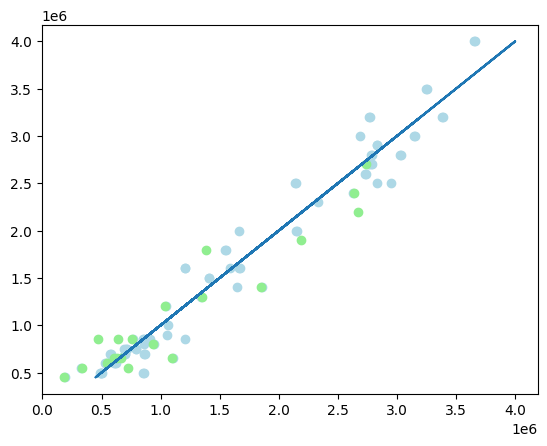

In [13]:
X_test = X_test.select_dtypes(include='number')

def train_model_show_rmse(inputs_train, inputs_test, targets_train, targets_test):
    model = LinearRegression().fit(inputs_train, targets_train)
    
    predictions_train = model.predict(inputs_train)
    loss_train = root_mean_squared_error(targets_train, predictions_train)
    print('Loss train:', loss_train)
    
    predictions_test = model.predict(inputs_test)
    loss_test = root_mean_squared_error(targets_test, predictions_test)
    print('Loss test:', loss_test)
    
    plt.scatter(predictions_train, targets_train, color='lightblue')
    plt.scatter(predictions_test, targets_test, color='lightgreen')
    plt.plot(cars_df.Price, cars_df.Price)
    return model
    
model1 = train_model_show_rmse(X_train, X_test, y_train, y_test)

Модель виглядає хорошою, хотілось би мати більшу точність, але я так розумію, для реальних даних це досить добре

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

Loss train: 210293.57828151854
Loss test: 258181.56112032768


,Feature,Coefficient
5,Power,496769.214899
16,Mercedes,210048.781148
10,BMW,208407.313783
9,Audi,205600.147769
8,Transmission_codes,116693.768206
20,Owner_Type_Codes,42344.952815
18,Toyota,15805.701511
1,Car_ID,5608.685421
2,Seats,-2148.924549
4,Year,-8765.645714


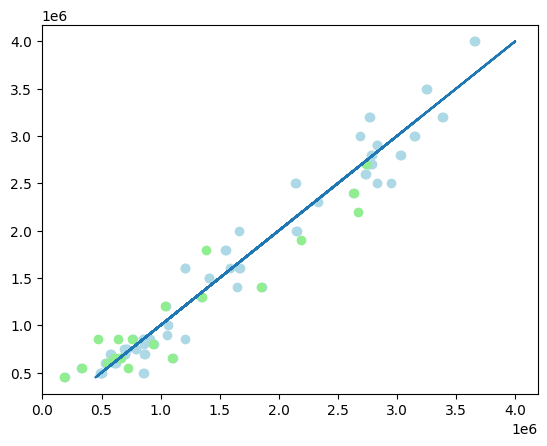

In [14]:
scaler = StandardScaler()
scaler.fit(X_train[X_train.columns])

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train[X_train.columns]),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test[X_test.columns]),
    columns=X_test.columns,
    index=X_test.index
)

model2 = train_model_show_rmse(X_train_scaled, X_test_scaled, y_train, y_test)

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model2.coef_[0]
})
coef_df.sort_values(by='Coefficient', ascending=False, inplace=True)
coef_df

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [15]:
Y = y_train
X = X_train_scaled
X = sm.add_constant(X)
model = sm.OLS(Y,X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     68.35
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           2.01e-33
Time:                        22:06:14   Log-Likelihood:                -1094.0
No. Observations:                  80   AIC:                             2230.
Df Residuals:                      59   BIC:                             2280.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                1.68e+06   2.74e+04     61.363      0.000    1.63e+06    1.73e+06
Kilometers_Driven   -9.44e+04   6.51e+04     -1.449      0.153   -2.25e+05    3.59e+04
Car_ID              5608.6854   3.37e+04      0.166      0.869   -6.19e+04    7.31e+04
Seats              -2148.9245   4.22e+04     -0.051      0.960   -8.66e+04    8.23e+04
Mileage            -1.317e+05   5.83e+04     -2.259      0.028   -2.48e+05    -1.5e+04
Year               -8765.6457   6.09e+04     -0.144      0.886   -1.31e+05    1.13e+05
Power               4.968e+05   7.54e+04      6.588      0.000    3.46e+05    6.48e+05
Engine             -2.138e+04   7.29e+04     -0.293      0.770   -1.67e+05    1.24e+05
Fuel_Type_codes    -1.838e+05   4.57e+04     -4.026      0.000   -2.75e+05   -9.25e+04
Transmission_codes  1.167e+05    4.4e+04      2.653      0.010    2.87e+04    2.05e+05
Audi                2.056e+05   3.05e+04      6.738      0.000    1.45e+05    2.67e+05
BMW                 2.084e+05   3.19e+04      6.532      0.000    1.45e+05    2.72e+05
Ford               -1.182e+05   3.37e+04     -3.507      0.001   -1.86e+05   -5.08e+04
Honda              -6.275e+04   3.44e+04     -1.825      0.073   -1.32e+05    6034.235
Hyundai            -1.523e+05    2.9e+04     -5.247      0.000    -2.1e+05   -9.42e+04
Mahindra           -1.409e+05   2.97e+04     -4.747      0.000      -2e+05   -8.15e+04
Maruti             -1.123e+05   2.91e+04     -3.856      0.000   -1.71e+05    -5.4e+04
Mercedes              2.1e+05   3.14e+04      6.682      0.000    1.47e+05    2.73e+05
Tata                 -6.6e+04   3.95e+04     -1.672      0.100   -1.45e+05     1.3e+04
Toyota              1.581e+04   3.47e+04      0.456      0.650   -5.36e+04    8.52e+04
Volkswagen         -9.297e+04      3e+04     -3.097      0.003   -1.53e+05   -3.29e+04
Owner_Type_Codes    4.234e+04   4.75e+04      0.892      0.376   -5.27e+04    1.37e+05
==============================================================================
Omnibus:                        0.187   Durbin-Watson:                   2.053
Prob(Omnibus):                  0.911   Jarque-Bera (JB):                0.311
Skew:                           0.104   Prob(JB):                        0.856
Kurtosis:                       2.776   Cond. No.                     9.98e+15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 3.02e-30. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

Згідно таблиці бачимо, що статистично значимими є коєфіцієнти для ['Power', 'Mileage', 'Fuel_Type_codes', 'Transmission_codes', 'Audi', 'BMW', 'Ford', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Volkswagen'].
Дивлячись на показники R2 і Adj. R-squared, здається, це досить хороша модель

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [16]:
columns_9 = ['Power', 'Mileage', 'Fuel_Type_codes', 'Transmission_codes', 'Audi', 'BMW',
        'Ford', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Volkswagen']

Y = y_train
X = X_train_scaled[columns_9]
X = sm.add_constant(X)
model = sm.OLS(Y,X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     109.4
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           4.12e-39
Time:                        22:06:14   Log-Likelihood:                -1100.4
No. Observations:                  80   AIC:                             2227.
Df Residuals:                      67   BIC:                             2258.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                1.68e+06   2.78e+04     60.360      0.000    1.62e+06    1.74e+06
Power               4.556e+05    5.1e+04      8.941      0.000    3.54e+05    5.57e+05
Mileage             -1.43e+05   4.02e+04     -3.561      0.001   -2.23e+05   -6.29e+04
Fuel_Type_codes    -1.337e+05   2.99e+04     -4.479      0.000   -1.93e+05   -7.41e+04
Transmission_codes  1.311e+05    4.3e+04      3.046      0.003    4.52e+04    2.17e+05
Audi                2.497e+05   3.53e+04      7.075      0.000    1.79e+05     3.2e+05
BMW                  2.95e+05   3.78e+04      7.802      0.000     2.2e+05     3.7e+05
Ford               -4.855e+04   3.52e+04     -1.378      0.173   -1.19e+05    2.18e+04
Hyundai            -1.027e+05   3.17e+04     -3.238      0.002   -1.66e+05   -3.94e+04
Mahindra           -8.538e+04   3.02e+04     -2.825      0.006   -1.46e+05    -2.5e+04
Maruti             -5.118e+04   3.07e+04     -1.665      0.101   -1.13e+05    1.02e+04
Mercedes            2.767e+05   3.68e+04      7.515      0.000    2.03e+05     3.5e+05
Volkswagen         -2.375e+04    3.4e+04     -0.699      0.487   -9.16e+04    4.41e+04
==============================================================================
Omnibus:                        1.178   Durbin-Watson:                   1.830
Prob(Omnibus):                  0.555   Jarque-Bera (JB):                1.084
Skew:                           0.279   Prob(JB):                        0.582
Kurtosis:                       2.879   Cond. No.                         3.68
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

R2 і Adj. R-squared практично не змінились, але покращилась F-statistic.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [17]:
columns_10 = columns_9 + ['Kilometers_Driven', 'Honda', 'Tata']
Y = y_train
X = X_train_scaled[columns_10]
X = sm.add_constant(X)
model = sm.OLS(Y,X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     97.03
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           4.85e-38
Time:                        22:06:14   Log-Likelihood:                -1094.7
No. Observations:                  80   AIC:                             2221.
Df Residuals:                      64   BIC:                             2260.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                1.68e+06   2.65e+04     63.341      0.000    1.63e+06    1.73e+06
Power               4.667e+05   4.93e+04      9.475      0.000    3.68e+05    5.65e+05
Mileage            -1.213e+05   4.52e+04     -2.685      0.009   -2.12e+05    -3.1e+04
Fuel_Type_codes    -1.629e+05   3.14e+04     -5.184      0.000   -2.26e+05      -1e+05
Transmission_codes  1.175e+05   4.15e+04      2.832      0.006    3.46e+04       2e+05
Audi                 1.95e+05   3.86e+04      5.051      0.000    1.18e+05    2.72e+05
BMW                 2.093e+05   4.53e+04      4.620      0.000    1.19e+05       3e+05
Ford                -1.14e+05      4e+04     -2.851      0.006   -1.94e+05   -3.41e+04
Hyundai            -1.518e+05    3.7e+04     -4.107      0.000   -2.26e+05    -7.8e+04
Mahindra           -1.444e+05   3.47e+04     -4.163      0.000   -2.14e+05   -7.51e+04
Maruti             -1.159e+05   3.64e+04     -3.189      0.002   -1.89e+05   -4.33e+04
Mercedes            2.048e+05    4.2e+04      4.874      0.000    1.21e+05    2.89e+05
Volkswagen         -9.073e+04   3.94e+04     -2.304      0.024   -1.69e+05   -1.21e+04
Kilometers_Driven  -7.887e+04   3.47e+04     -2.275      0.026   -1.48e+05   -9600.782
Honda              -7.975e+04   3.83e+04     -2.085      0.041   -1.56e+05   -3324.825
Tata               -9.701e+04   4.27e+04     -2.269      0.027   -1.82e+05   -1.16e+04
==============================================================================
Omnibus:                        0.317   Durbin-Watson:                   2.011
Prob(Omnibus):                  0.853   Jarque-Bera (JB):                0.436
Skew:                           0.137   Prob(JB):                        0.804
Kurtosis:                       2.763   Cond. No.                         5.98
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Показники змінились ще менше за показники завдання 9 порівняно з завданням 8. Мені здається, різниця була би більш відчутна, якби даних було набагато більше. Щодо вибору моделі, то мені хочеться взяти попередню (завдання 9) - там хоч показники R2 і Adj. R-squared  трохи гірші, зате краще F-statistic набагаио краща.
Також натренувавши модель за допомогою sklearn використовуючи різні набори колонок, мені найбільше подобається варіант з columns_9, там loss_train більше, зате loss_test покращилось - я думаю, це важливо для нових оцінок

Loss train: 212184.2641894934
Loss test: 250977.9544449181


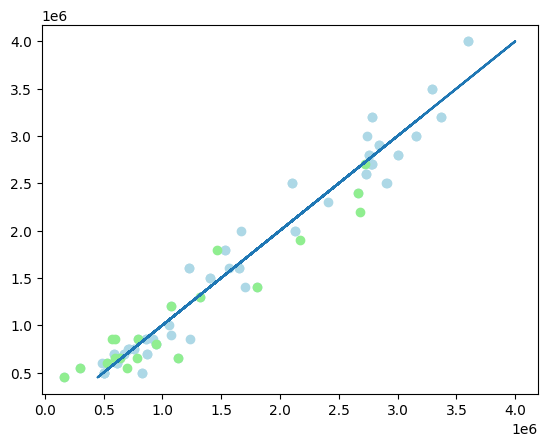

In [18]:
model_9 = train_model_show_rmse(X_train_scaled[columns_10], X_test_scaled[columns_10], y_train, y_test)

Loss train: 227824.3018043997
Loss test: 233241.86184464034


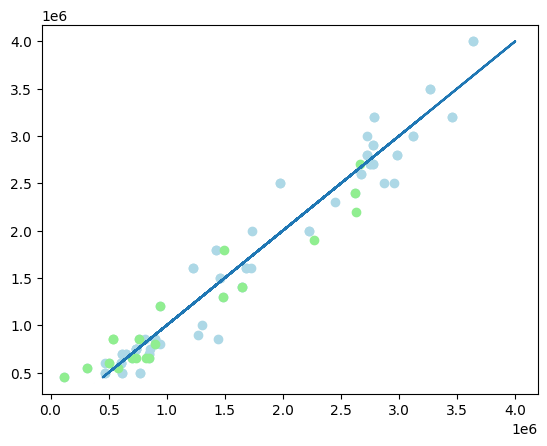

In [19]:
model_10 = train_model_show_rmse(X_train_scaled[columns_9], X_test_scaled[columns_9], y_train, y_test)